<a href="https://colab.research.google.com/github/Nirupamaistack/Digital-Communication/blob/main/DPCM%20and%20Delta%20Modulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

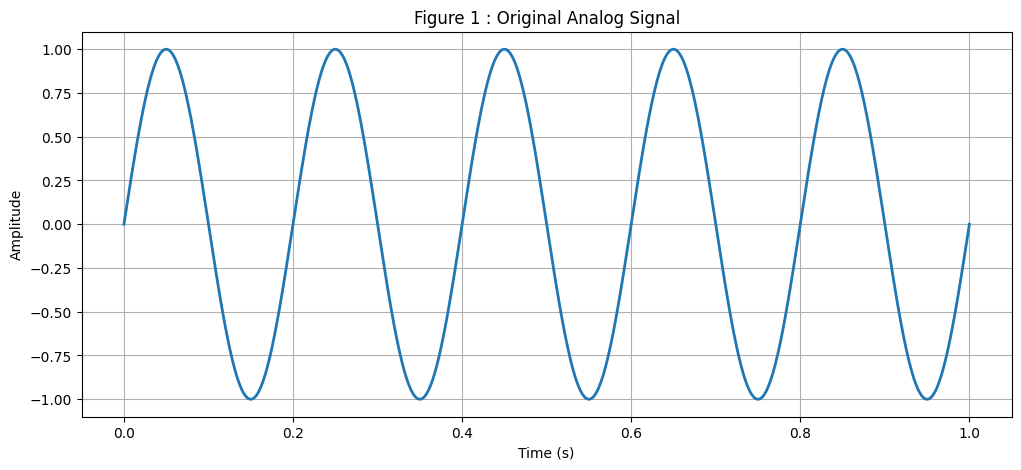

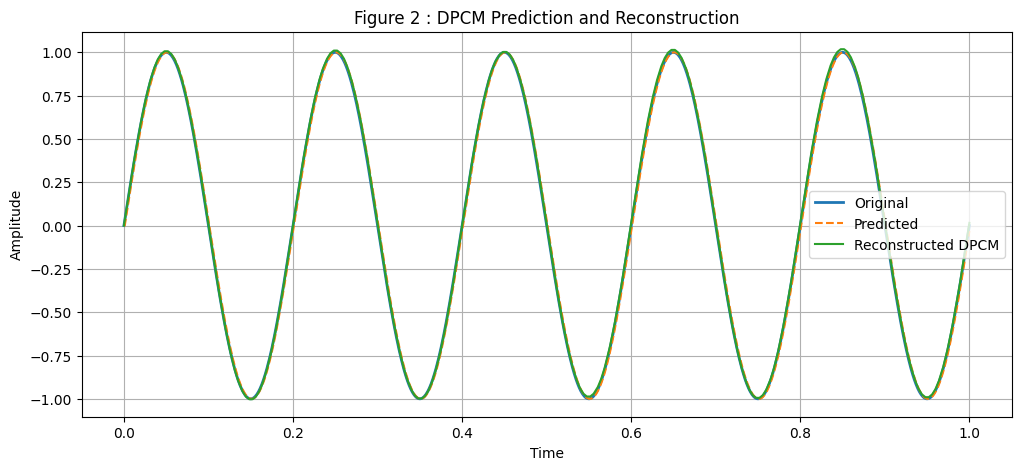

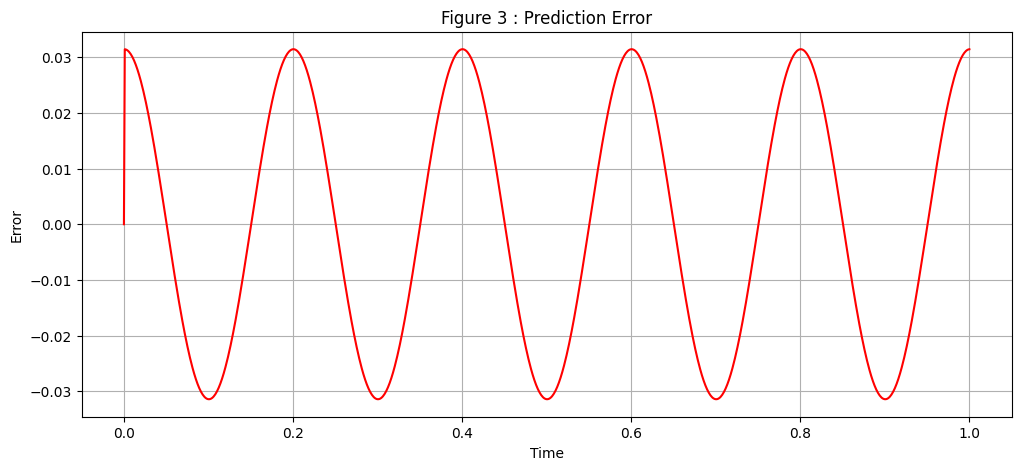

========== PCM vs DPCM ==========
PCM Mean Square Error  : 0.0011923791590905195
DPCM Mean Square Error : 0.0001083320355259029


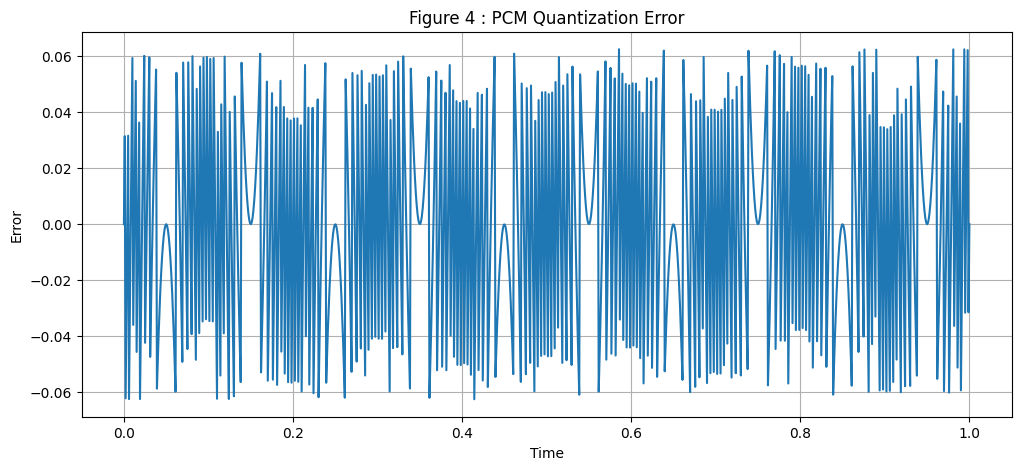

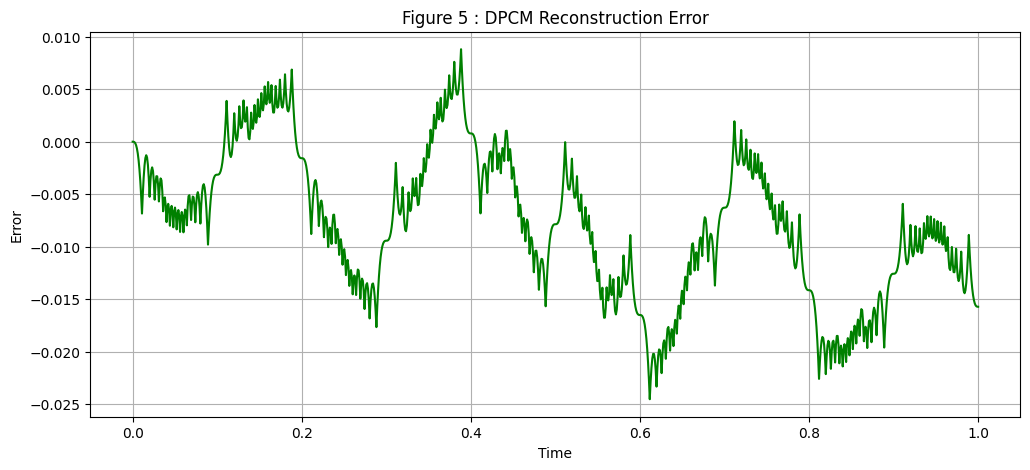

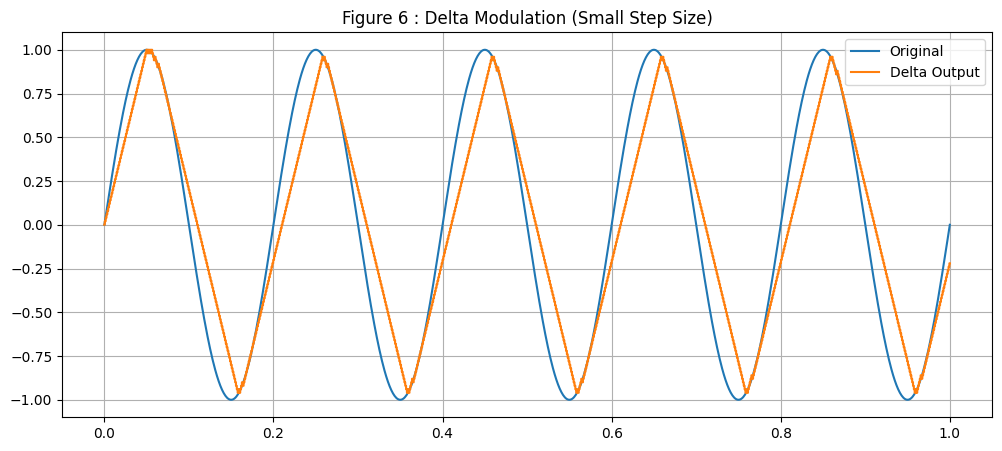

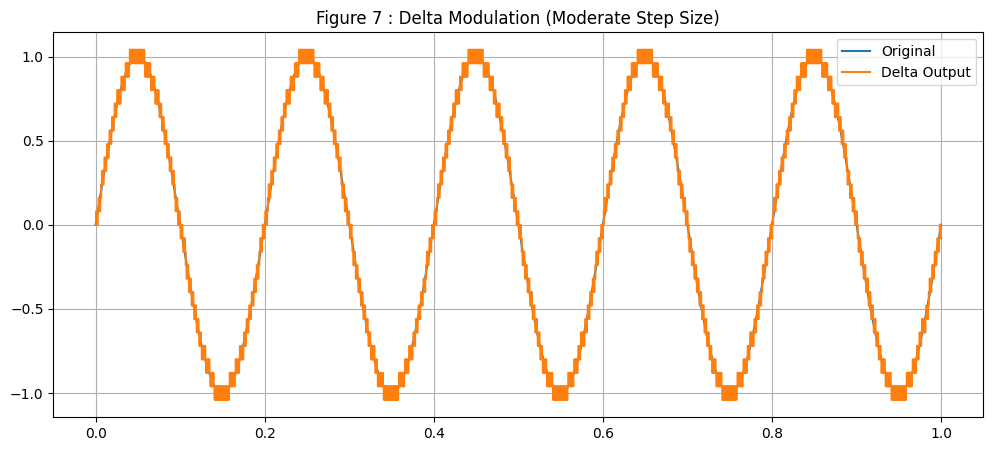

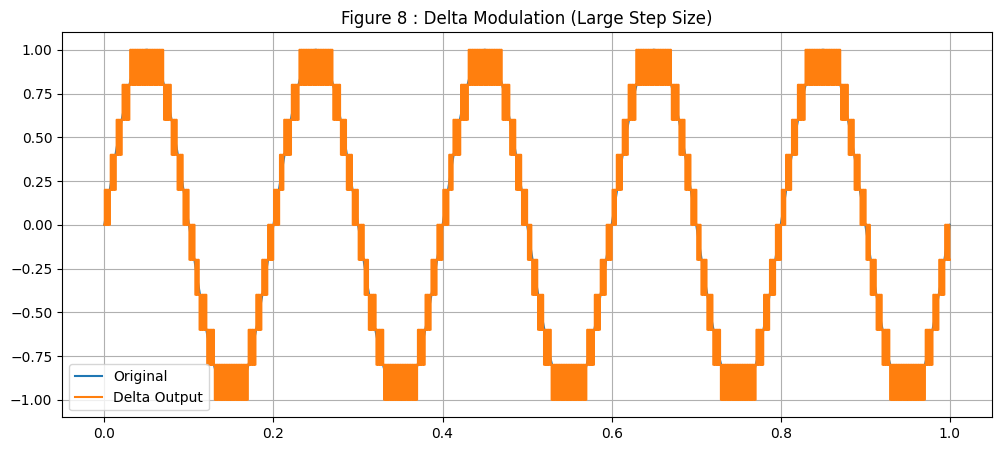

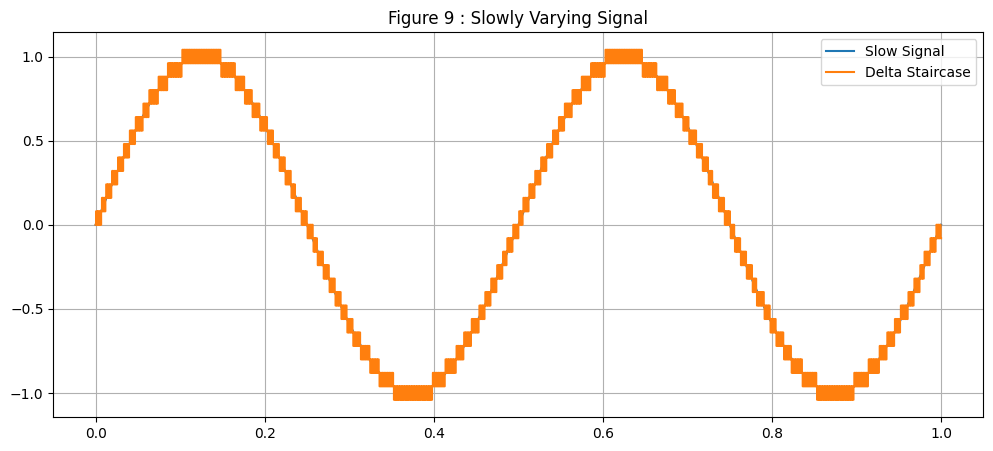

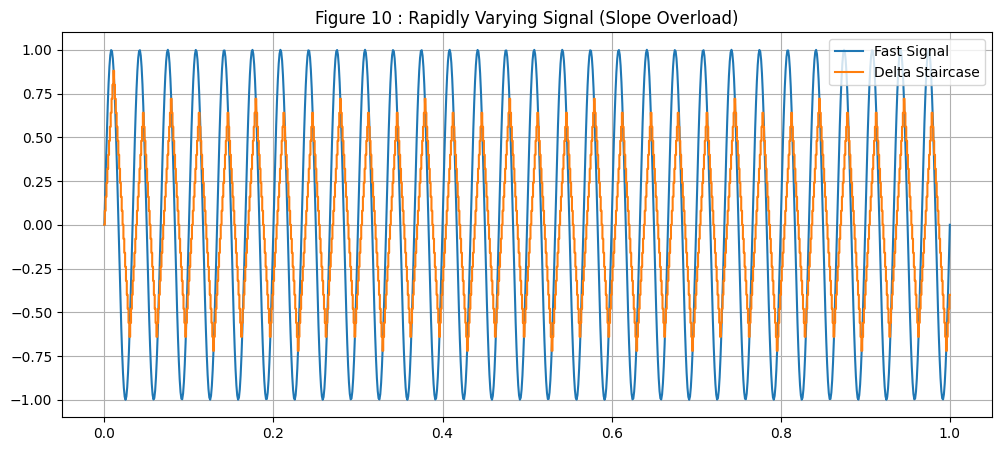

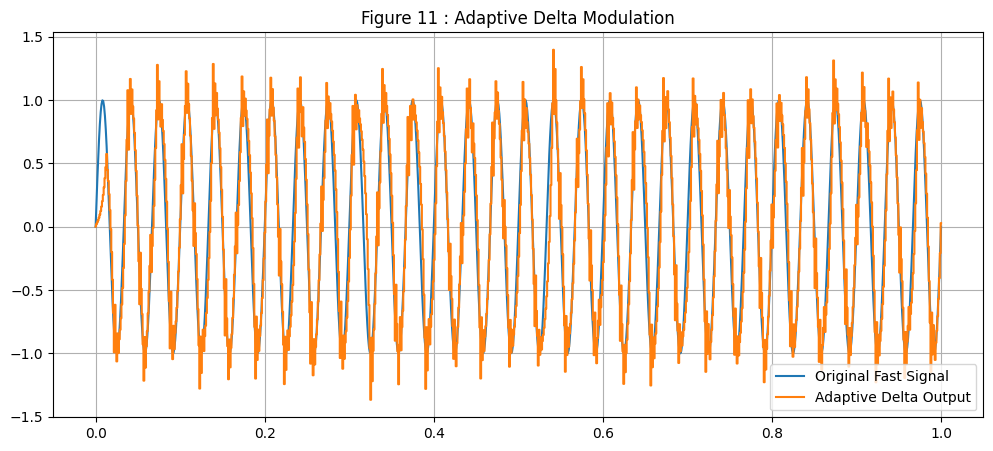

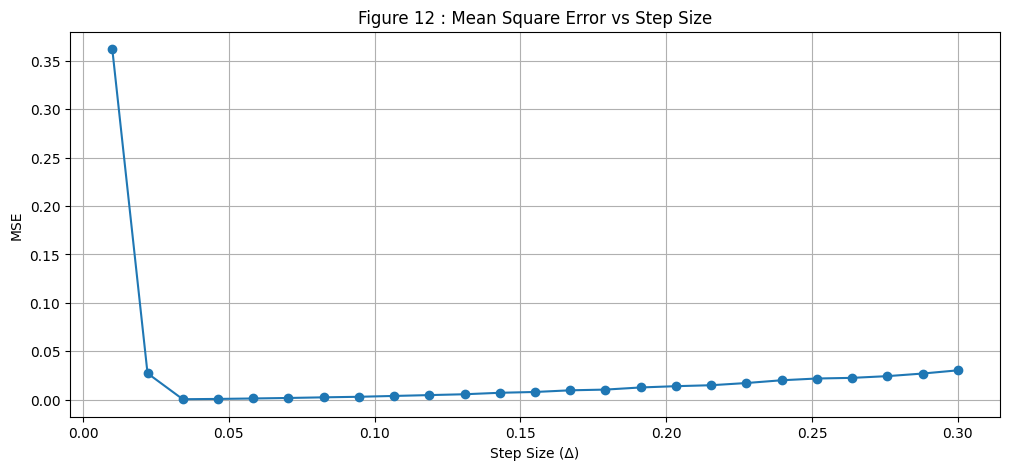


========== VALIDATION ==========
Every staircase change equals +Δ or -Δ : True


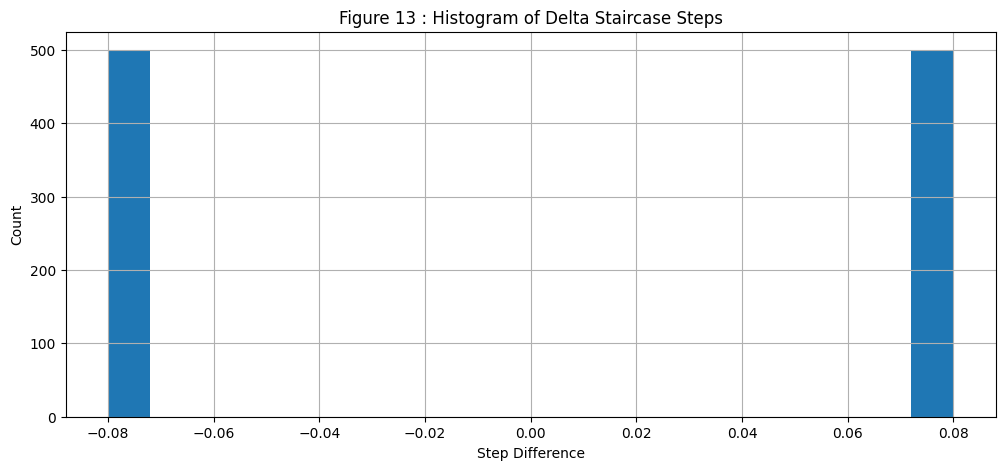


First 30 Delta Modulation Bits:
[1 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1]

========== EXPERIMENT COMPLETED SUCCESSFULLY ==========


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 5 : DPCM AND DELTA MODULATION
# Digital Communication Laboratory (MAKAUT ECE)
# ============================================================

plt.rcParams['figure.figsize'] = (12,5)

# ------------------------------------------------------------
# Generate Test Signal
# ------------------------------------------------------------
fs = 1000                     # Sampling Frequency
t = np.linspace(0,1,fs)

frequency = 5                 # Signal Frequency
signal = np.sin(2*np.pi*frequency*t)

# ------------------------------------------------------------
# Figure 1 : Original Signal
# ------------------------------------------------------------
plt.figure()
plt.plot(t, signal, linewidth=2)
plt.title("Figure 1 : Original Analog Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# ============================================================
# PART A : FIRST ORDER DPCM
# ============================================================

prediction = np.zeros_like(signal)
prediction[1:] = signal[:-1]

prediction_error = signal - prediction

bits = 4
levels = 2**bits

max_amp = np.max(np.abs(prediction_error))
step = (2*max_amp)/levels

quantized_error = np.round(prediction_error/step)*step

reconstructed = np.zeros_like(signal)

for i in range(1,len(signal)):
    reconstructed[i] = reconstructed[i-1] + quantized_error[i]

# ------------------------------------------------------------
# Figure 2 : Original vs Prediction vs Reconstruction
# ------------------------------------------------------------
plt.figure()
plt.plot(t, signal, label="Original", linewidth=2)
plt.plot(t, prediction, label="Predicted", linestyle="--")
plt.plot(t, reconstructed, label="Reconstructed DPCM")
plt.title("Figure 2 : DPCM Prediction and Reconstruction")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Figure 3 : Prediction Error
# ------------------------------------------------------------
plt.figure()
plt.plot(t, prediction_error, color='red')
plt.title("Figure 3 : Prediction Error")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# PCM vs DPCM Error
# ------------------------------------------------------------
pcm_step = (2*np.max(np.abs(signal)))/levels
pcm_quantized = np.round(signal/pcm_step)*pcm_step

pcm_error = signal - pcm_quantized
dpcm_error = signal - reconstructed

pcm_mse = np.mean(pcm_error**2)
dpcm_mse = np.mean(dpcm_error**2)

print("========== PCM vs DPCM ==========")
print("PCM Mean Square Error  :", pcm_mse)
print("DPCM Mean Square Error :", dpcm_mse)

# ------------------------------------------------------------
# Figure 4 : PCM Quantization Error
# ------------------------------------------------------------
plt.figure()
plt.plot(t, pcm_error)
plt.title("Figure 4 : PCM Quantization Error")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Figure 5 : DPCM Reconstruction Error
# ------------------------------------------------------------
plt.figure()
plt.plot(t, dpcm_error, color='green')
plt.title("Figure 5 : DPCM Reconstruction Error")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# ============================================================
# PART B : DELTA MODULATION
# ============================================================

def delta_modulation(x, delta):

    y = np.zeros_like(x)
    bits = []

    for i in range(1,len(x)):
        if x[i] >= y[i-1]:
            y[i] = y[i-1] + delta
            bits.append(1)
        else:
            y[i] = y[i-1] - delta
            bits.append(0)

    return y, np.array(bits)

# ------------------------------------------------------------
# Small Step Size (Granular Noise)
# ------------------------------------------------------------
delta_small = 0.02
y_small, bits_small = delta_modulation(signal, delta_small)

plt.figure()
plt.plot(t, signal, label="Original")
plt.step(t, y_small, label="Delta Output", where='mid')
plt.title("Figure 6 : Delta Modulation (Small Step Size)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Moderate Step Size
# ------------------------------------------------------------
delta_mid = 0.08
y_mid, bits_mid = delta_modulation(signal, delta_mid)

plt.figure()
plt.plot(t, signal, label="Original")
plt.step(t, y_mid, label="Delta Output", where='mid')
plt.title("Figure 7 : Delta Modulation (Moderate Step Size)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Large Step Size
# ------------------------------------------------------------
delta_large = 0.20
y_large, bits_large = delta_modulation(signal, delta_large)

plt.figure()
plt.plot(t, signal, label="Original")
plt.step(t, y_large, label="Delta Output", where='mid')
plt.title("Figure 8 : Delta Modulation (Large Step Size)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# PART C : SLOWLY AND RAPIDLY VARYING SIGNALS
# ============================================================

slow_signal = np.sin(2*np.pi*2*t)
fast_signal = np.sin(2*np.pi*30*t)

y_slow, bits_slow = delta_modulation(slow_signal, delta_mid)
y_fast, bits_fast = delta_modulation(fast_signal, delta_mid)

# ------------------------------------------------------------
# Slowly Varying Signal
# ------------------------------------------------------------
plt.figure()
plt.plot(t, slow_signal, label="Slow Signal")
plt.step(t, y_slow, label="Delta Staircase", where='mid')
plt.title("Figure 9 : Slowly Varying Signal")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Rapidly Varying Signal (Slope Overload)
# ------------------------------------------------------------
plt.figure()
plt.plot(t, fast_signal, label="Fast Signal")
plt.step(t, y_fast, label="Delta Staircase", where='mid')
plt.title("Figure 10 : Rapidly Varying Signal (Slope Overload)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# PART D : ADAPTIVE DELTA MODULATION (OPTIONAL BONUS)
# ============================================================

def adaptive_delta_modulation(x, delta0=0.02):

    y = np.zeros_like(x)
    delta = delta0
    prev_bit = 0
    bits = []

    for i in range(1,len(x)):

        if x[i] >= y[i-1]:
            bit = 1
            y[i] = y[i-1] + delta
        else:
            bit = 0
            y[i] = y[i-1] - delta

        if bit == prev_bit:
            delta = delta*1.2
        else:
            delta = delta*0.7

        delta = max(delta,0.01)
        prev_bit = bit
        bits.append(bit)

    return y, np.array(bits)

adm_output, adm_bits = adaptive_delta_modulation(fast_signal)

plt.figure()
plt.plot(t, fast_signal, label="Original Fast Signal")
plt.step(t, adm_output, label="Adaptive Delta Output", where='mid')
plt.title("Figure 11 : Adaptive Delta Modulation")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# PART E : MSE VS STEP SIZE
# ============================================================

step_sizes = np.linspace(0.01,0.30,25)
mse = []

for d in step_sizes:
    y,_ = delta_modulation(signal,d)
    mse.append(np.mean((signal-y)**2))

plt.figure()
plt.plot(step_sizes, mse, marker='o')
plt.title("Figure 12 : Mean Square Error vs Step Size")
plt.xlabel("Step Size (Δ)")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# ============================================================
# PART F : VALIDATION OF DELTA MODULATION
# ============================================================

difference = np.diff(y_mid)

validation = np.all(np.isclose(np.abs(difference[1:]), delta_mid))

print("\n========== VALIDATION ==========")
print("Every staircase change equals +Δ or -Δ :", validation)

# ------------------------------------------------------------
# Histogram of Staircase Steps
# ------------------------------------------------------------
plt.figure()
plt.hist(difference, bins=20)
plt.title("Figure 13 : Histogram of Delta Staircase Steps")
plt.xlabel("Step Difference")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Display first 30 transmitted bits
# ------------------------------------------------------------
print("\nFirst 30 Delta Modulation Bits:")
print(bits_mid[:30])
